In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

In [6]:
#load public transport patronage csv file
df = pd.read_csv(r'avg_patronage.csv', dtype='string', na_values=["", "NA", "N/A", "null", "NULL", "NaN"], keep_default_na=True, low_memory=False )
df.shape

(4300, 7)

In [ ]:
#data exploration after enforcing and adding new column
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         4300 non-null   int64         
 1   Month        4300 non-null   int64         
 2   Month_name   4300 non-null   string        
 3   Day_of_week  4300 non-null   category      
 4   Day_type     4300 non-null   category      
 5   Mode         4300 non-null   category      
 6   Pax_daily    4300 non-null   string        
 7   MonthStart   4300 non-null   datetime64[ns]
dtypes: category(3), datetime64[ns](1), int64(2), string(2)
memory usage: 181.4 KB
None


In [10]:
#enforce year and month column to int datatype
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
#enforce day of week, day type, mode to category data type
df['Day_of_week'] = df['Day_of_week'].astype('category')
df['Day_type'] = df['Day_type'].astype('category')
df['Mode'] = df['Mode'].astype('category')
#create new column showing first day in month
df['MonthStart'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype('str') + '-01'
)

In [ ]:
#check exact duplicaes
print(df.duplicated().sum())

#check null
print(df.isna().sum())
print(df['Pax_daily'].isna().sum())

#check anomalies
print(df['Pax_daily'].describe())


#clean labels
cols = ['Day_of_week', 'Day_type', 'Mode']
for col in cols:
    df[col] = df[col].str.strip().str.title()

0
Year               0
Month              0
Month_name         0
Day_of_week        0
Day_type           0
Mode               0
Pax_daily          0
Month_name_enc     0
Day_of_week_enc    0
Day_type_enc       0
Mode_enc           0
MonthStart         0
dtype: int64
0
count      4300
unique     3181
top       62050
freq          7
Name: Pax_daily, dtype: object


In [3]:
#verify after cleaning
print(df.isna().sum())
print(df.duplicated().sum())
print(df['Mode'].unique())

Year           0
Month          0
Month_name     0
Day_of_week    0
Day_type       0
Mode           0
Pax_daily      0
MonthStart     0
dtype: int64
0
['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']
Categories (5, string): [MetroBus, MetroTrain, RegionalBus, RegionalTrain, Tram]


In [12]:
#Engineering feature
#Period
df['Period'] = pd.cut(
    df['Year'],
    bins=[0, 2019, 2021, float('inf')],
    labels=['Pre-2020', '2020-2021', 'Post-2021']
)
print(df['Period'].head())

#is weekday(1) or not(0)
df['Is_Weekday'] = df['Day_of_week'].isin(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
).astype(int)
print(df['Is_Weekday'].head(20))

#rolling mean
df = df.sort_values('MonthStart')

df['Rolling_3M'] = (
    df.groupby(['Mode', 'Day_type'])['Pax_daily']
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

0    Pre-2020
1    Pre-2020
2    Pre-2020
3    Pre-2020
4    Pre-2020
Name: Period, dtype: category
Categories (3, object): ['Pre-2020' < '2020-2021' < 'Post-2021']
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    0
16    0
17    0
18    0
19    0
Name: Is_Weekday, dtype: int64


In [ ]:
df.to_csv('patronage_cleaned.csv', index = False)

In [20]:
# Encode categorical columns
le = LabelEncoder()

cat_cols = ["Month_name", "Day_of_week", "Day_type", "Mode", "Period"]
for col in cat_cols:
    if col in df.columns:
        df[col + "_enc"] = le.fit_transform(df[col].astype(str))

# Convert Is_Weekday to int if boolean
if "Is_Weekday" in df.columns:
    df["Is_Weekday"] = df["Is_Weekday"].map({True: 1, False: 0, "TRUE": 1, "FALSE": 0})

# Define features and target
feature_cols = [
    "Year", "Month",
    "Month_name_enc", "Day_of_week_enc", "Day_type_enc",
    "Mode_enc", "Period_enc",
    "Is_Weekday",
    "Rolling_3M"
]

# Only keep features that actually exist in df
feature_cols = [f for f in feature_cols if f in df.columns]

target = "Pax_daily"

df_model = df[feature_cols + [target]].dropna()

X = df_model[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y = pd.to_numeric(df_model[target], errors="coerce").fillna(0)

# Debug: confirm all numeric
print("\nX dtypes after conversion:")
print(X.dtypes)
print(f"\nFeatures used: {feature_cols}")
print(f"Dataset size after dropna: {len(df_model)}")


X dtypes after conversion:
Year                 int64
Month                int64
Month_name_enc       int64
Day_of_week_enc      int64
Day_type_enc         int64
Mode_enc             int64
Period_enc           int64
Is_Weekday           int64
Rolling_3M         float64
dtype: object

Features used: ['Year', 'Month', 'Month_name_enc', 'Day_of_week_enc', 'Day_type_enc', 'Mode_enc', 'Period_enc', 'Is_Weekday', 'Rolling_3M']
Dataset size after dropna: 4300


In [14]:
#desciptive analysis
df['Pax_daily'] = pd.to_numeric(df['Pax_daily'], errors='coerce')
df.dropna()

df.groupby(['Mode','Day_type','Day_of_week','Period'])['Pax_daily'].agg(['mean','median']).reset_index()



,Mode,Day_type,Day_of_week,Period,mean,median
0,Metrobus,Normal Weekday,Friday,Pre-2020,429502.272727,437150.0
1,Metrobus,Normal Weekday,Friday,2020-2021,205858.333333,196275.0
2,Metrobus,Normal Weekday,Friday,Post-2021,355588.636364,364950.0
3,Metrobus,Normal Weekday,Monday,Pre-2020,426526.086957,435250.0
4,Metrobus,Normal Weekday,Monday,2020-2021,187572.727273,171650.0
...,...,...,...,...,...,...
310,Tram,Weekend,Tuesday,2020-2021,<NA>,<NA>
311,Tram,Weekend,Tuesday,Post-2021,<NA>,<NA>
312,Tram,Weekend,Wednesday,Pre-2020,<NA>,<NA>
313,Tram,Weekend,Wednesday,2020-2021,<NA>,<NA>


Month
1      85628050
2      74803650
3      82680500
4     123382200
5      68372200
6      76452500
7     112570650
8      63814250
9     104093600
10     92949550
11     68674800
12     81727000
Name: Pax_daily, dtype: Int64


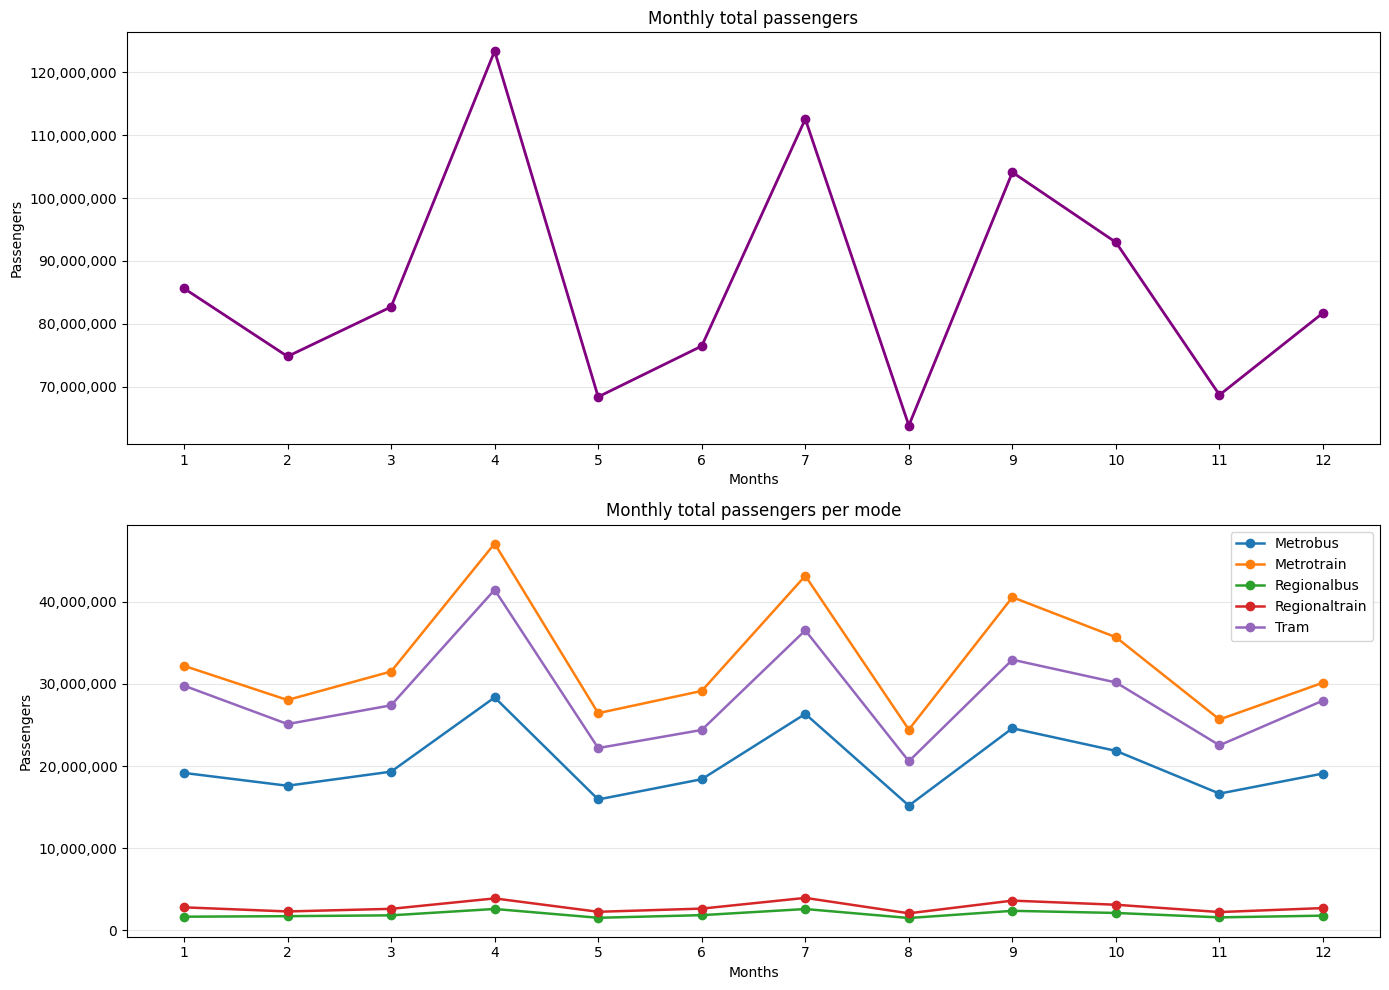

In [15]:
#A. Descriptive analytics(LO1)

summary_mode = (
    df.groupby("Mode", observed=True)["Pax_daily"]
    .agg(["mean", "median"])
    .round(0)
    .reset_index()
)
 
summary_day_type = (
    df.groupby("Day_type", observed=True)["Pax_daily"]
    .agg(["mean", "median"])
    .round(0)
    .reset_index()
)

summary_week_day = (
    df.groupby("Day_of_week", observed=True)["Pax_daily"]
    .agg(["mean", "median"])
    .round(0)
    .reset_index()
)

period_order = ["Pre-2020", "2020-2021", "Post-2021"]
summary_period = (
    df.groupby("Period", observed=True)["Pax_daily"]
    .agg(["mean", "median"])
    .round(0)
    .reindex(period_order)
    .reset_index()
)

monthly_passengers = df.groupby('Month')['Pax_daily'].sum()
monthly_pax_mode = df.groupby(['Month','Mode'])['Pax_daily'].sum().unstack()

print(monthly_passengers)


#Summary tables: mean/median Pax_daily ;by Mode, Day_type, Day_of_week, and Period.
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(monthly_passengers.index, monthly_passengers.values, color="purple", linewidth=2, marker="o")
axes[0].set_title("Monthly total passengers")
axes[0].set_xlabel("Months")
axes[0].set_ylabel("Passengers")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xticks(range(1, 13))

#Trend lines: time‑series of monthly; Pax_daily (overall and split by Mode).
for mode in monthly_pax_mode.columns:
    axes[1].plot(monthly_pax_mode.index, monthly_pax_mode[mode], label=mode, linewidth=1.8, marker="o")
axes[1].set_title("Monthly total passengers per mode")
axes[1].set_xlabel("Months")
axes[1].set_ylabel("Passengers")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()



C:\Users\qvu29\AppData\Local\Temp\ipykernel_17644\3022147609.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_by_mode = df.groupby(["MonthStart", "Mode"])["Pax_daily"].mean().unstack()


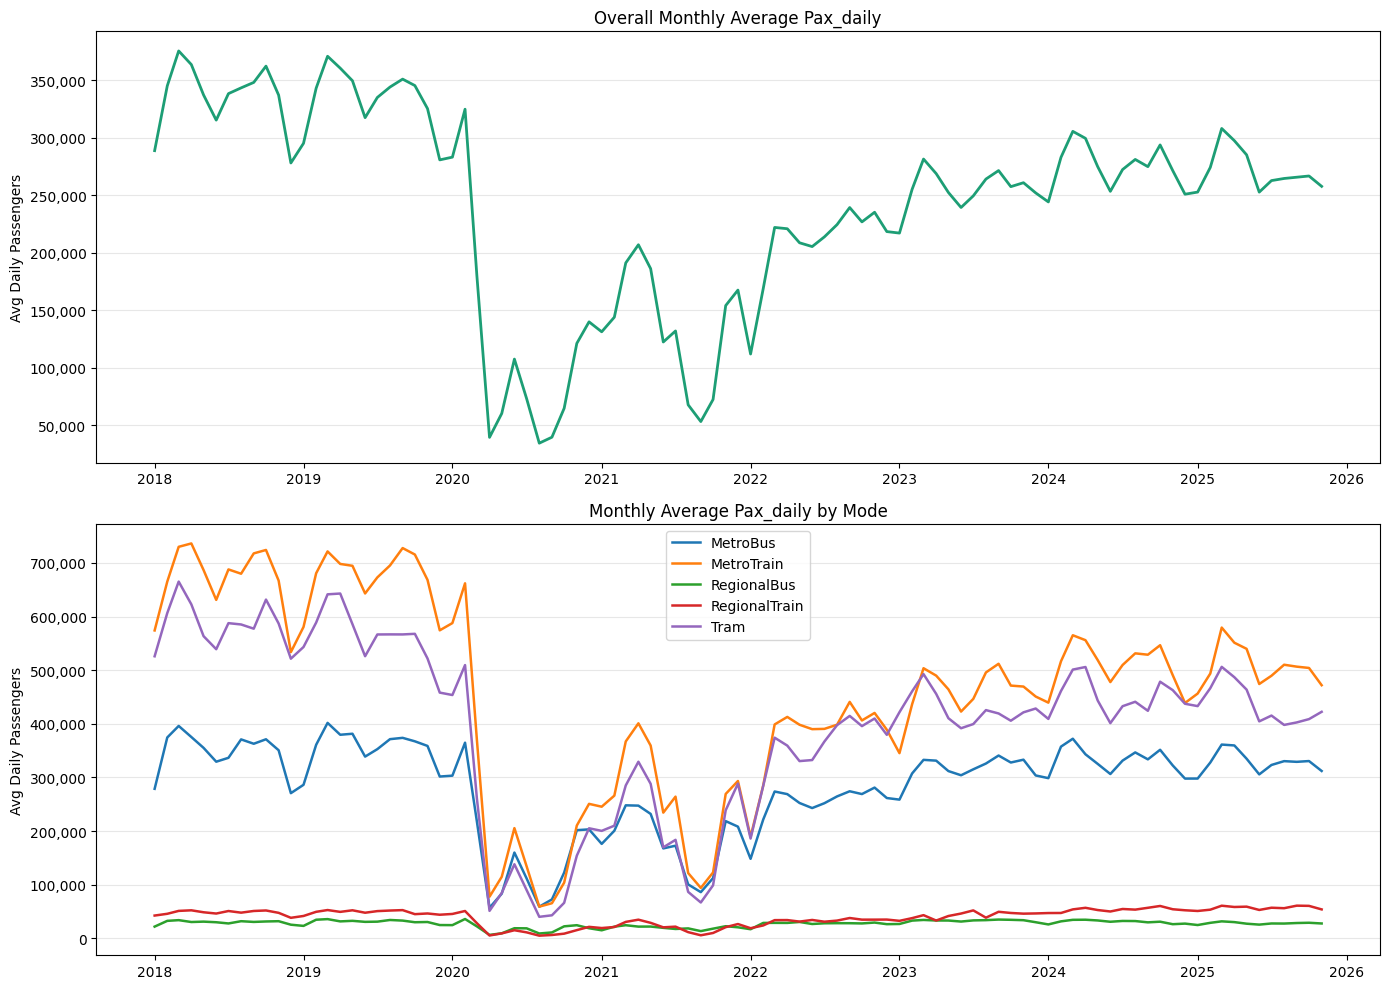

C:\Users\qvu29\AppData\Local\Temp\ipykernel_17644\3022147609.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(["Day_of_week", "Mode"])["Pax_daily"].mean().unstack()


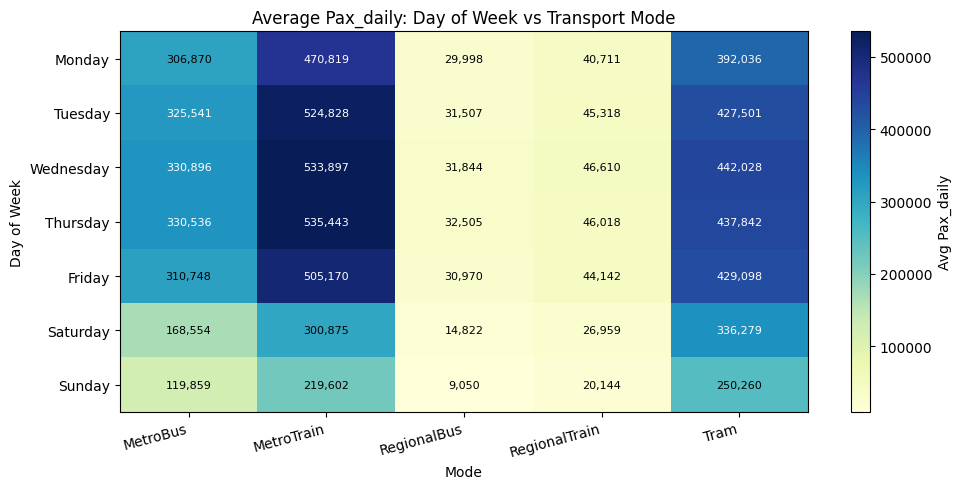

C:\Users\qvu29\AppData\Local\Temp\ipykernel_17644\3022147609.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ci_data = df.groupby(["Mode", "Day_type"])["Pax_daily"].agg(


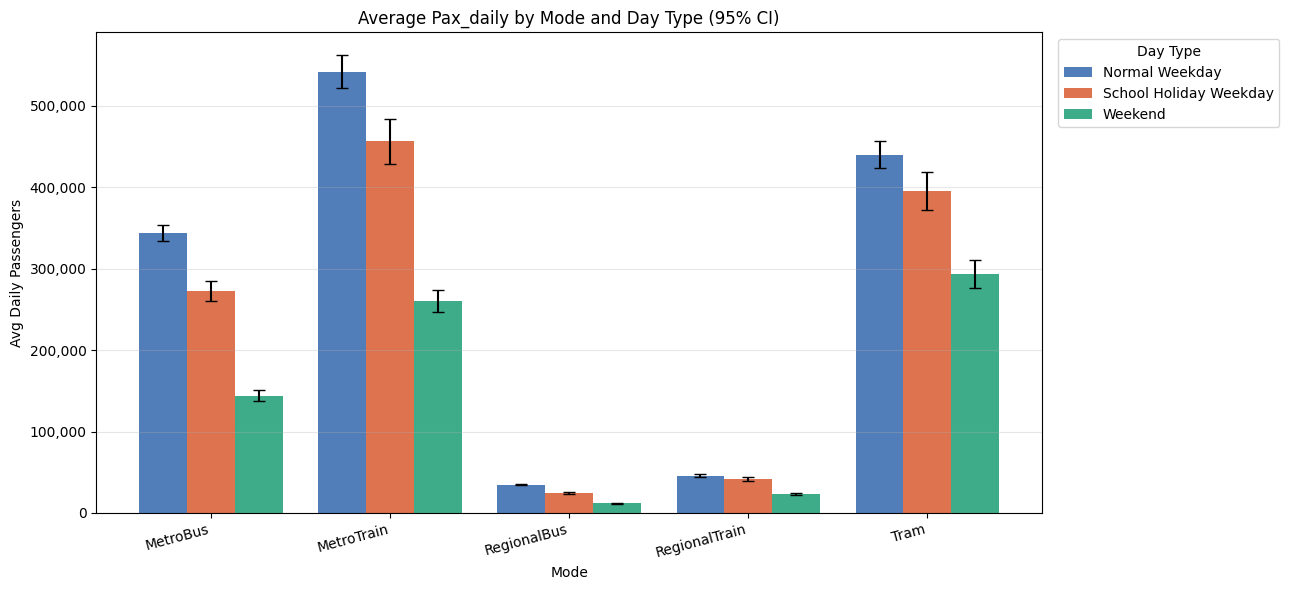

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. TREND LINES — overall + by Mode
# ══════════════════════════════════════════════════════════════════════════════

monthly_overall = df.groupby("MonthStart")["Pax_daily"].mean()
monthly_by_mode = df.groupby(["MonthStart", "Mode"])["Pax_daily"].mean().unstack()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(monthly_overall.index, monthly_overall.values, color="#1D9E75", linewidth=2)
axes[0].set_title("Overall Monthly Average Pax_daily")
axes[0].set_ylabel("Avg Daily Passengers")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)

for mode in monthly_by_mode.columns:
    axes[1].plot(monthly_by_mode.index, monthly_by_mode[mode], label=mode, linewidth=1.8)
axes[1].set_title("Monthly Average Pax_daily by Mode")
axes[1].set_ylabel("Avg Daily Passengers")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 3. HEATMAP — Day_of_week vs Mode
# ══════════════════════════════════════════════════════════════════════════════

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = df.groupby(["Day_of_week", "Mode"])["Pax_daily"].mean().unstack()
pivot = pivot.reindex(day_order)
pivot = pivot.astype(float)  # fix: force float, handles any object dtype or NaNs

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu")
plt.colorbar(im, ax=ax, label="Avg Pax_daily")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=15, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:,.0f}", ha="center", va="center", fontsize=8,
                    color="white" if val > np.nanmax(pivot.values) * 0.6 else "black")

ax.set_title("Average Pax_daily: Day of Week vs Transport Mode")
ax.set_xlabel("Mode")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4. BAR CHART WITH 95% CI — Day_type by Mode
# ══════════════════════════════════════════════════════════════════════════════

def ci95(group):
    n = len(group)
    std = group.std()
    # t-critical for 95% CI (approx 1.96 for large n, conservative for small)
    t_crit = 1.96 if n > 30 else (2.093 if n > 19 else 2.262)
    return t_crit * std / np.sqrt(n)

ci_data = df.groupby(["Mode", "Day_type"])["Pax_daily"].agg(
    mean="mean", ci=ci95
).reset_index()

modes     = sorted(ci_data["Mode"].unique())
day_types = sorted(ci_data["Day_type"].unique())
x         = np.arange(len(modes))
width     = 0.8 / len(day_types)
colors    = ["#3266ad", "#D85A30", "#1D9E75", "#BA7517", "#888780"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, dt in enumerate(day_types):
    sub  = ci_data[ci_data["Day_type"] == dt].set_index("Mode").reindex(modes)
    bars = x + i * width
    ax.bar(bars, sub["mean"], width, label=dt,
           yerr=sub["ci"], capsize=4, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x + width * (len(day_types) - 1) / 2)
ax.set_xticklabels(modes, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Average Pax_daily by Mode and Day Type (95% CI)")
ax.set_xlabel("Mode")
ax.set_ylabel("Avg Daily Passengers")
ax.legend(title="Day Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

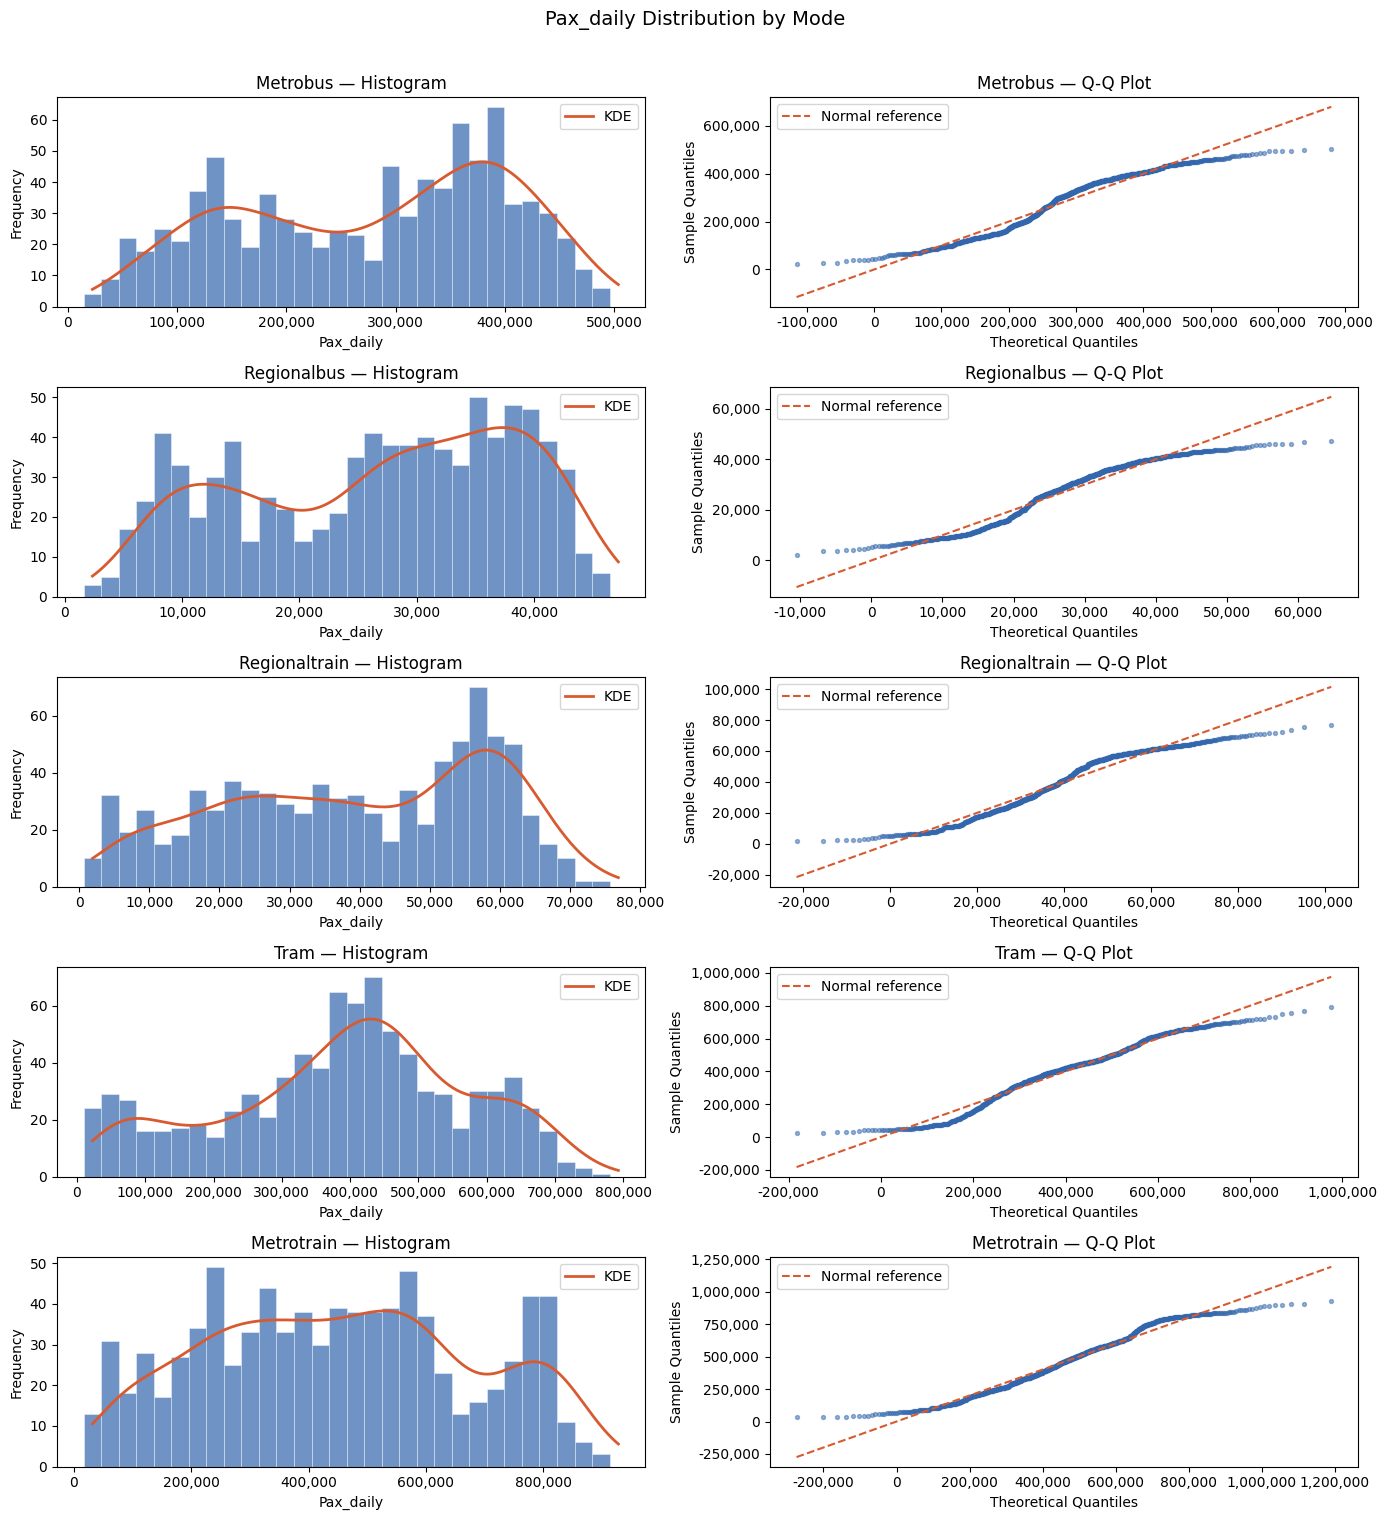

=== Linear Regression Results (per Mode) ===

Mode: Metrobus
  Slope (Pax/day): 9.00  [95% CI: -0.83, 18.83]
  Intercept:       269,156
  R²:              0.0037
  Interpretation:  Pax_daily increases by 9.00 passengers per calendar day on average.

Mode: Regionalbus
  Slope (Pax/day): 1.41  [95% CI: 0.48, 2.34]
  Intercept:       25,069
  R²:              0.0103
  Interpretation:  Pax_daily increases by 1.41 passengers per calendar day on average.

Mode: Regionaltrain
  Slope (Pax/day): 5.48  [95% CI: 4.00, 6.96]
  Intercept:       32,127
  R²:              0.0579
  Interpretation:  Pax_daily increases by 5.48 passengers per calendar day on average.

Mode: Tram
  Slope (Pax/day): -25.17  [95% CI: -39.42, -10.91]
  Intercept:       432,387
  R²:              0.0138
  Interpretation:  Pax_daily decreases by 25.17 passengers per calendar day on average.

Mode: Metrotrain
  Slope (Pax/day): -40.20  [95% CI: -58.13, -22.27]
  Intercept:       515,397
  R²:              0.0220
  Interpretat

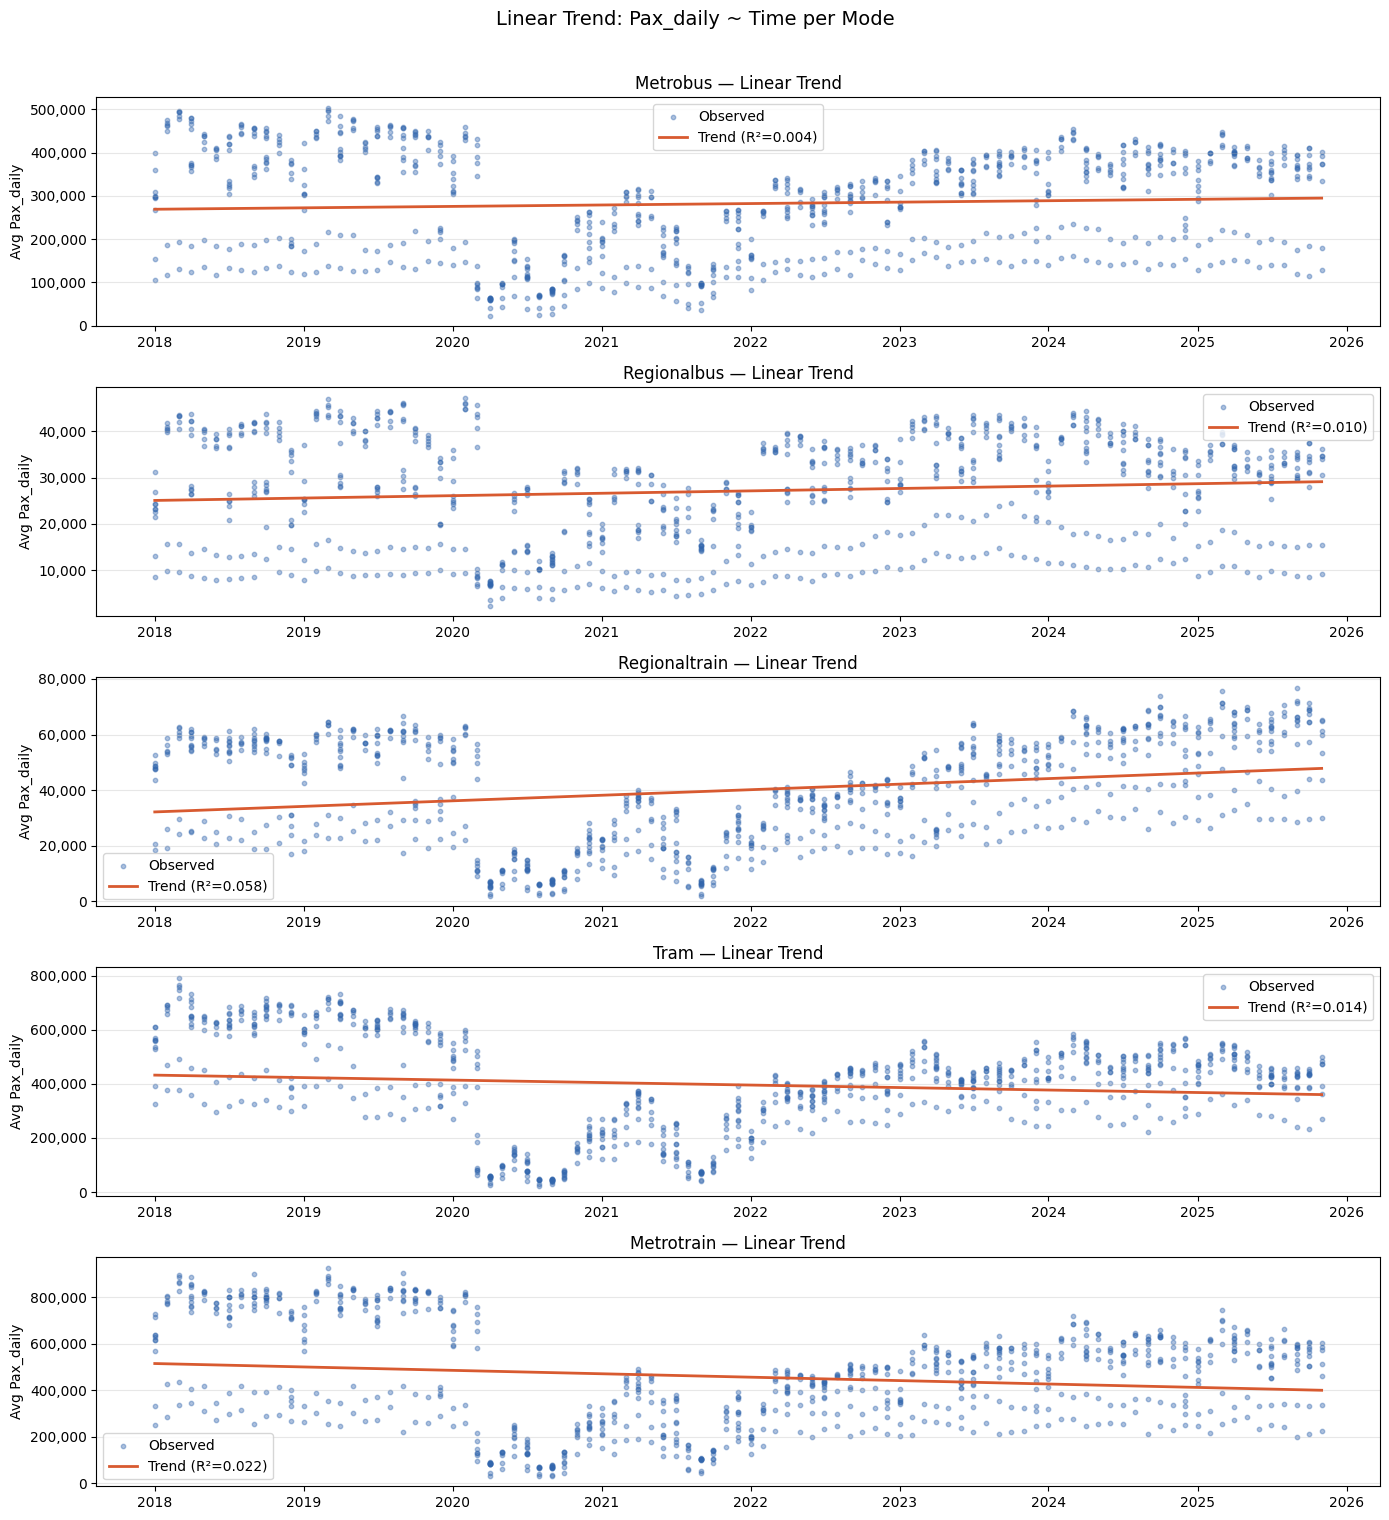

In [29]:
#1. HISTOGRAM + MANUAL KDE — overall and by Mode
modes = df["Mode"].unique()
fig, axes = plt.subplots(len(modes), 2, figsize=(14, len(modes) * 3))
fig.suptitle("Pax_daily Distribution by Mode", fontsize=14, y=1.01)

def manual_kde(data, x_grid, bandwidth=None):
    """Gaussian KDE using only numpy."""
    data = data[~np.isnan(data)]
    if bandwidth is None:
        # Silverman's rule
        bandwidth = 1.06 * data.std() * len(data) ** (-1/5)
    kde = np.array([
        np.mean(np.exp(-0.5 * ((x - data) / bandwidth) ** 2) / (bandwidth * np.sqrt(2 * np.pi)))
        for x in x_grid
    ])
    return kde

for i, mode in enumerate(modes):
    vals = df[df["Mode"] == mode]["Pax_daily"].dropna().values

    # Histogram
    ax_h = axes[i, 0]
    counts, bin_edges = np.histogram(vals, bins=30)
    ax_h.bar(bin_edges[:-1], counts, width=np.diff(bin_edges),
             color="#3266ad", alpha=0.7, edgecolor="white", linewidth=0.4)
    ax_h.set_title(f"{mode} — Histogram")
    ax_h.set_xlabel("Pax_daily")
    ax_h.set_ylabel("Frequency")
    ax_h.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # KDE (density scaled to histogram)
    x_grid = np.linspace(vals.min(), vals.max(), 300)
    kde_vals = manual_kde(vals, x_grid)
    bin_width = np.diff(bin_edges).mean()
    scale = len(vals) * bin_width          # scale KDE to match histogram counts
    ax_h.plot(x_grid, kde_vals * scale, color="#D85A30", linewidth=2, label="KDE")
    ax_h.legend()

    # Q-Q plot (manual — no scipy)
    ax_q = axes[i, 1]
    sorted_vals = np.sort(vals)
    n = len(sorted_vals)
    # Theoretical quantiles from standard normal using rational approximation
    probs = (np.arange(1, n + 1) - 0.5) / n
    # Beasley-Springer-Moro approximation for inverse normal CDF
    def norm_ppf(p):
        a = [2.515517, 0.802853, 0.010328]
        b = [1.432788, 0.189269, 0.001308]
        t = np.where(p < 0.5, np.sqrt(-2 * np.log(p)), np.sqrt(-2 * np.log(1 - p)))
        num = a[0] + a[1]*t + a[2]*t**2
        den = 1 + b[0]*t + b[1]*t**2 + b[2]*t**3
        z = t - num / den
        return np.where(p < 0.5, -z, z)

    theoretical_q = norm_ppf(probs)
    # Scale theoretical quantiles to match data scale
    theoretical_scaled = theoretical_q * vals.std() + vals.mean()

    ax_q.scatter(theoretical_scaled, sorted_vals, s=8, alpha=0.5, color="#3266ad")
    # Reference line (45-degree)
    ref_min = min(theoretical_scaled.min(), sorted_vals.min())
    ref_max = max(theoretical_scaled.max(), sorted_vals.max())
    ax_q.plot([ref_min, ref_max], [ref_min, ref_max], color="#D85A30",
              linewidth=1.5, linestyle="--", label="Normal reference")
    ax_q.set_title(f"{mode} — Q-Q Plot")
    ax_q.set_xlabel("Theoretical Quantiles")
    ax_q.set_ylabel("Sample Quantiles")
    ax_q.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_q.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_q.legend()

plt.tight_layout()
plt.savefig("distributions_qq.png", dpi=150)
plt.show()


#2. LINEAR REGRESSION — Pax_daily ~ MonthStart per Mode (numpy only)


# Convert MonthStart to numeric (days since first date)
df["t"] = (df["MonthStart"] - df["MonthStart"].min()).dt.days

fig, axes = plt.subplots(len(modes), 1, figsize=(14, len(modes) * 3))
fig.suptitle("Linear Trend: Pax_daily ~ Time per Mode", fontsize=14, y=1.01)

print("=== Linear Regression Results (per Mode) ===\n")

for i, mode in enumerate(modes):
    sub = df[df["Mode"] == mode][["t", "Pax_daily"]].dropna()
    x = sub["t"].values.astype(float)
    y = sub["Pax_daily"].values.astype(float)
    n = len(x)

    # OLS: β = (XᵀX)⁻¹Xᵀy
    X = np.column_stack([np.ones(n), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    intercept, slope = beta

    y_hat = X @ beta
    residuals = y - y_hat
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    # 95% CI on slope
    se2 = ss_res / (n - 2)
    var_slope = se2 / np.sum((x - x.mean()) ** 2)
    se_slope = np.sqrt(var_slope)
    t_crit = 1.96 if n > 30 else 2.262      # conservative
    ci_low  = slope - t_crit * se_slope
    ci_high = slope + t_crit * se_slope

    print(f"Mode: {mode}")
    print(f"  Slope (Pax/day): {slope:.2f}  [95% CI: {ci_low:.2f}, {ci_high:.2f}]")
    print(f"  Intercept:       {intercept:,.0f}")
    print(f"  R²:              {r2:.4f}")
    print(f"  Interpretation:  Pax_daily {'increases' if slope > 0 else 'decreases'} "
          f"by {abs(slope):.2f} passengers per calendar day on average.\n")

    # Plot
    ax = axes[i]
    ax.scatter(df[df["Mode"] == mode]["MonthStart"],
               df[df["Mode"] == mode]["Pax_daily"],
               s=10, alpha=0.4, color="#3266ad", label="Observed")
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = intercept + slope * x_line
    date_line = pd.to_datetime(df["MonthStart"].min()) + pd.to_timedelta(x_line, unit="D")
    ax.plot(date_line, y_line, color="#D85A30", linewidth=2, label=f"Trend (R²={r2:.3f})")
    ax.set_title(f"{mode} — Linear Trend")
    ax.set_ylabel("Avg Pax_daily")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("linear_trends.png", dpi=150)
plt.show()

In [ ]:
#time-aware split
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


Train size: 3440 | Test size: 860


In [ ]:
#train models
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)


── Linear Regression ──
  MAE : 17,192
  RMSE: 26,734
  R²  : 0.9839


In [25]:
# Assume 1 bus handles 50 passengers per trip, 10 trips/day = 500 pax/day per bus
BUS_CAPACITY = 500

results = pd.DataFrame({
    "Actual_Pax": y_test.values,
    "LR_Predicted_Pax": lr_pred.astype(int),
    "XGB_Predicted_Pax": xgb_pred.astype(int),
}).reset_index(drop=True)

# How many buses needed each day based on each model
results["Buses_LR"]  = (results["LR_Predicted_Pax"]  / BUS_CAPACITY).apply(np.ceil).astype(int)
results["Buses_XGB"] = (results["XGB_Predicted_Pax"] / BUS_CAPACITY).apply(np.ceil).astype(int)
results["Buses_Actual"] = (results["Actual_Pax"] / BUS_CAPACITY).apply(np.ceil).astype(int)

# Over/under deployment (negative = under-deployed = bad, passengers left behind)
results["LR_Over_Under"]  = results["Buses_LR"]  - results["Buses_Actual"]
results["XGB_Over_Under"] = results["Buses_XGB"] - results["Buses_Actual"]

print("=" * 60)
print("       BUS DEPLOYMENT PLAN (sample — first 10 days)")
print("=" * 60)
print(results[["Actual_Pax", "LR_Predicted_Pax", "XGB_Predicted_Pax",
               "Buses_Actual", "Buses_LR", "Buses_XGB"]].head(10).to_string(index=False))

print("\n── Deployment Error Summary ──")
print(f"LR  — avg buses over/under per day : {results['LR_Over_Under'].mean():+.2f}")
print(f"XGB — avg buses over/under per day : {results['XGB_Over_Under'].mean():+.2f}")
print(f"\nDays LR under-deployed  (risk of overcrowding): {(results['LR_Over_Under'] < 0).sum()}")
print(f"Days XGB under-deployed (risk of overcrowding): {(results['XGB_Over_Under'] < 0).sum()}")

       BUS DEPLOYMENT PLAN (sample — first 10 days)
 Actual_Pax  LR_Predicted_Pax  XGB_Predicted_Pax  Buses_Actual  Buses_LR  Buses_XGB
     347100            342248             339565           695       685        680
     354900            343472             342472           710       687        685
      10800             16823              11863            22        34         24
     475750            511758             467307           952      1024        935
     245700            302172             300216           492       605        601
     152650            185926             167730           306       372        336
      41000             38262              34546            82        77         70
      18000             17394              19047            36        35         39
     479500            412361             444337           959       825        889
     382700            335095             381969           766       671        764

── Deployment Error Sum

In [26]:
#metrics
print("\n── Model Accuracy ──")
for name, pred in [("Linear Regression", lr_pred), ("XGBoost", xgb_pred)]:
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    print(f"{name:20s} | MAE: {mae:,.0f} pax | RMSE: {rmse:,.0f} pax | R²: {r2:.4f}")


── Model Accuracy ──
Linear Regression    | MAE: 17,192 pax | RMSE: 26,734 pax | R²: 0.9839
XGBoost              | MAE: 10,728 pax | RMSE: 17,213 pax | R²: 0.9933


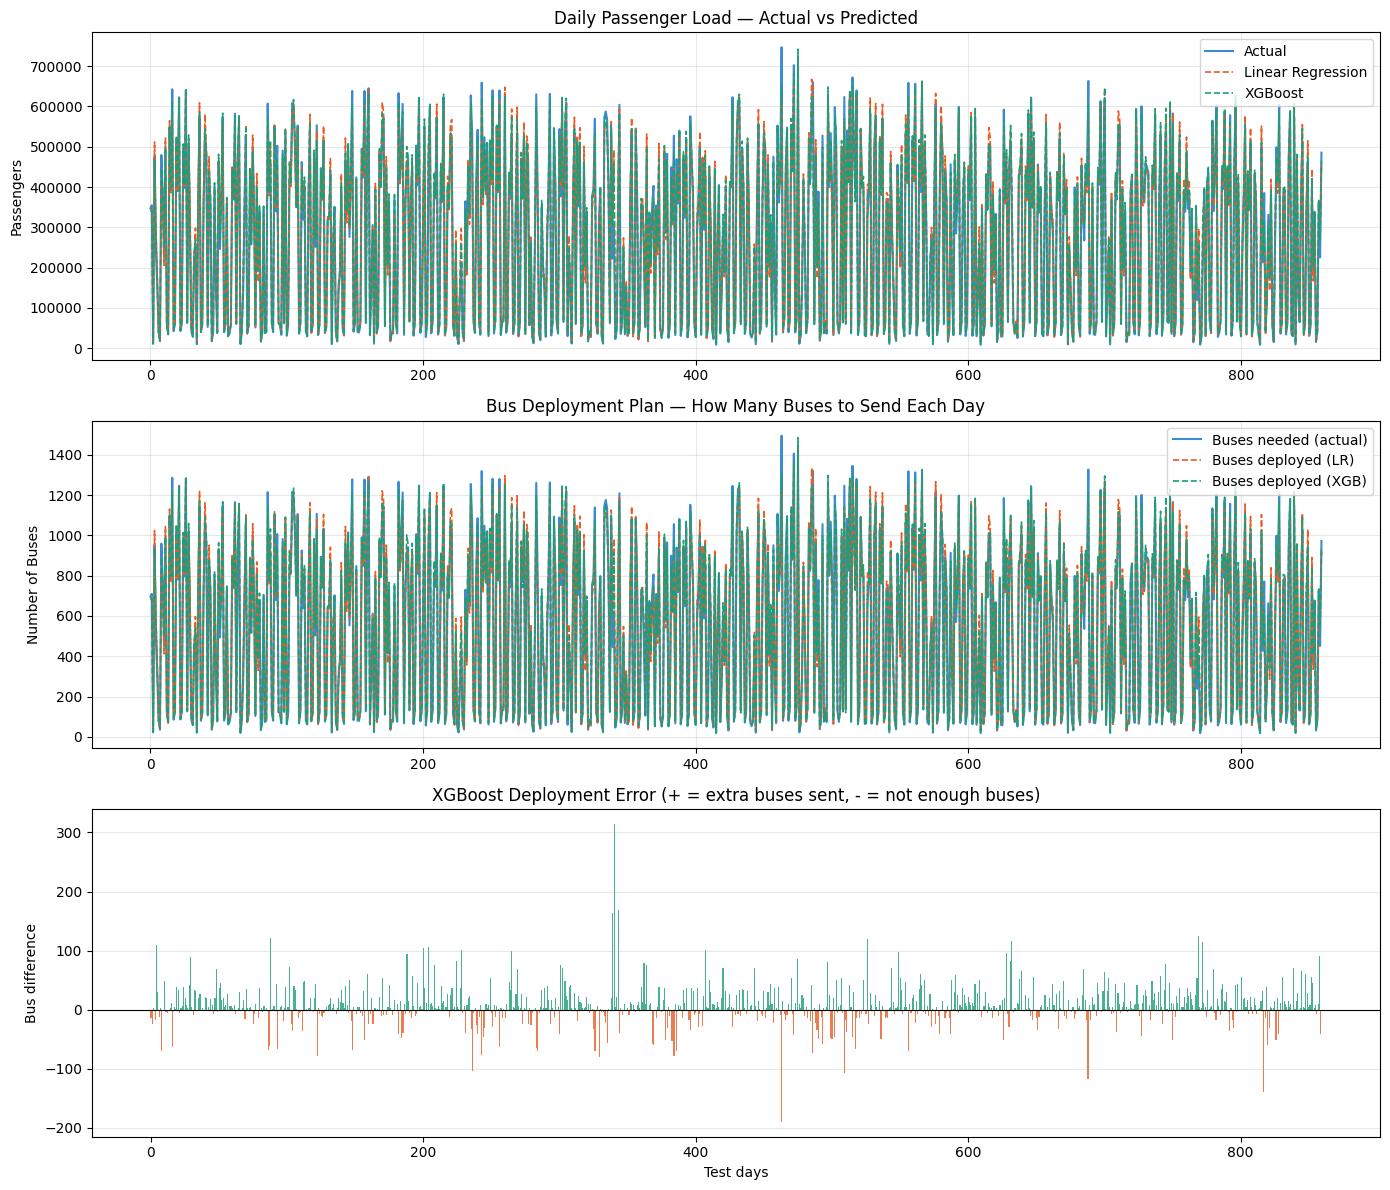

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
x_axis = range(len(y_test))

# Plot 1: Actual vs predicted passengers
axes[0].plot(x_axis, y_test.values, label="Actual", color="#3B8BD4", linewidth=1.5)
axes[0].plot(x_axis, lr_pred,  label="Linear Regression", color="#E85D24", linewidth=1.2, linestyle="--")
axes[0].plot(x_axis, xgb_pred, label="XGBoost",           color="#1D9E75", linewidth=1.2, linestyle="--")
axes[0].set_title("Daily Passenger Load — Actual vs Predicted", fontsize=12)
axes[0].set_ylabel("Passengers")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Buses needed per day
axes[1].plot(x_axis, results["Buses_Actual"], label="Buses needed (actual)", color="#3B8BD4", linewidth=1.5)
axes[1].plot(x_axis, results["Buses_LR"],     label="Buses deployed (LR)",   color="#E85D24", linewidth=1.2, linestyle="--")
axes[1].plot(x_axis, results["Buses_XGB"],    label="Buses deployed (XGB)",  color="#1D9E75", linewidth=1.2, linestyle="--")
axes[1].set_title("Bus Deployment Plan — How Many Buses to Send Each Day", fontsize=12)
axes[1].set_ylabel("Number of Buses")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Over/under deployment
axes[2].bar(x_axis, results["XGB_Over_Under"], color=[
    "#1D9E75" if v >= 0 else "#E85D24" for v in results["XGB_Over_Under"]
], alpha=0.8, label="XGB over/under")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("XGBoost Deployment Error (+ = extra buses sent, - = not enough buses)", fontsize=12)
axes[2].set_ylabel("Bus difference")
axes[2].set_xlabel("Test days")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

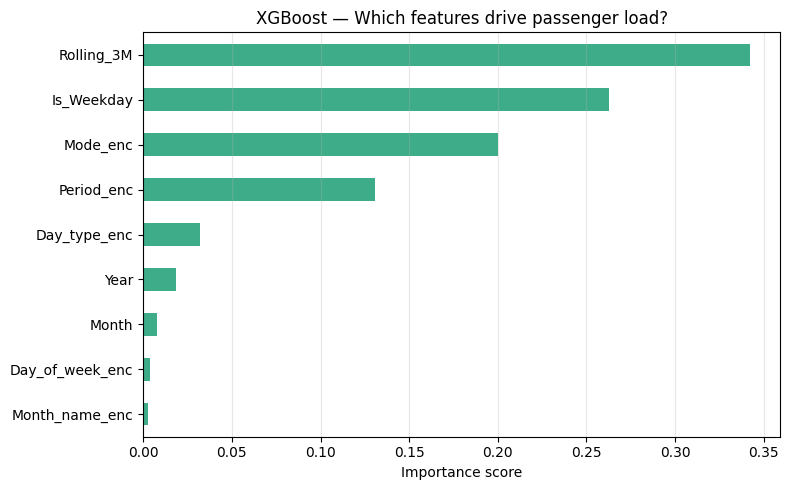

In [28]:
fi = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values()
fig2, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind="barh", color="#1D9E75", ax=ax, alpha=0.85)
ax.set_title("XGBoost — Which features drive passenger load?", fontsize=12)
ax.set_xlabel("Importance score")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()